In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Loss
from scipy.optimize import minimize
from tensorflow.keras.initializers import GlorotUniform, GlorotNormal
from joblib import Parallel, delayed
import time
import keras.backend as K

In [11]:
def g(x):
    return np.abs(x) ** (2 / 3)

In [12]:
# Define DPD custom loss function as a class
class CustomLoss(Loss):
    def __init__(self, sigma, alpha):
        super().__init__()
        self.alpha = alpha
        self.sigma = float(sigma)

    def call(self, y_true, y_pred):
        diff = (y_true - y_pred)/self.sigma
        diff_sq = tf.clip_by_value(diff**2, 1e-10, 1e6)  # Prevents extreme values
        normal_dist = tf.exp(-0.5 * diff_sq)
        normal_dist = tf.clip_by_value(normal_dist, 1e-10, 1.0)  # Keep in safe range
        loss = 1/((self.sigma**self.alpha)*((1+self.alpha)**0.5)) - (1+1/self.alpha)*tf.reduce_mean((normal_dist/self.sigma)**self.alpha)
        # Debugging
        #tf.print("Loss:", loss)
        #loss = tf.debugging.check_numerics(loss, "NaN detected in loss function!")
        return loss

class HuberLoss(Loss):
    def __init__(self, delta=1.345, sig=None):
        super().__init__()
        self.delta = delta
        self.sig = sig

    def call(self, y_true, y_pred):
        error = (y_true - y_pred)/(self.sig + K.epsilon())
        # Huber loss computation
        is_small_error = tf.abs(error) <= self.delta
        squared_loss = 0.5 * tf.square(error)
        linear_loss = self.delta * (tf.abs(error) - 0.5 * self.delta)
        loss = tf.where(is_small_error, squared_loss, linear_loss)
        return tf.reduce_mean(loss)

class TukeyLoss(Loss):
    def __init__(self, delta=4.685, sig=None):
        super().__init__()
        self.delta = delta
        self.sig = sig

    def call(self, y_true, y_pred):
        error = (y_true - y_pred)/(self.sig + K.epsilon())
        # Apply Tukey's biweight function
        mask = tf.abs(error) <= self.delta
        loss = tf.where(mask, (self.delta**2 / 6) * (1 - (1 - (error / self.delta) ** 2) ** 3), self.delta**2 / 6)
        return tf.reduce_mean(loss)  # Return mean loss over batch

class LMLSLoss(Loss):
    def __init__(self):
        super().__init__()

    def call(self, y_true, y_pred):
        r = y_pred - y_true  # Compute residual error
        loss = tf.math.log(1 + (r**2) / 2)  # Apply LMLS formula
        return tf.reduce_mean(loss)  # Take mean loss over batch

class LTSLoss(Loss):
    def __init__(self, h):
        super().__init__()
        self.h = h

    def call(self, y_true, y_pred):
        residuals = tf.square(y_true - y_pred)  # Compute squared residuals
        sorted_residuals = tf.sort(residuals)   # Sort in ascending order
        #num_elements = tf.size(residuals)
        #k = tf.minimum(self.h, num_elements)
        k = self.h
        trimmed_residuals = sorted_residuals[:k]  # Keep only k smallest residuals
        return tf.reduce_mean(trimmed_residuals)  # Compute mean of the kept residuals

class LTALoss(Loss):
    def __init__(self, h):
        super().__init__()
        self.h = h

    def call(self, y_true, y_pred):
        residuals = tf.abs(y_true - y_pred)  # Compute absolute residuals
        sorted_residuals = tf.sort(residuals)   # Sort in ascending order
        #num_elements = tf.size(residuals)
        #k = tf.minimum(self.h, num_elements)
        k = self.h
        trimmed_residuals = sorted_residuals[:k]  # Keep only k smallest residuals
        return tf.reduce_mean(trimmed_residuals)  # Compute mean of the kept residuals

def trimmed_mean(arr, trim_fraction):
    arr_sorted = np.sort(arr)  # Step 1: Sort array
    trim_count = int(len(arr) * trim_fraction)  # Step 2: Compute number of elements to trim
    
    if trim_count == 0:  # Ensure at least one element is trimmed if possible
        return np.mean(arr)
    
    trimmed_arr = arr_sorted[:-trim_count]  # Step 3: Remove largest 20%
    return np.mean(trimmed_arr)  # Step 4: Compute mean of remaining elements

def H(sigma, alpha, diff):
    normal_dist = np.exp(-0.5 * (diff / sigma) ** 2) / sigma
    loss = 1 / ((sigma ** alpha) * np.sqrt(1 + alpha)) - (1 + 1 / alpha) * np.mean(normal_dist ** alpha)
    return loss

def sig_hat_MAD(resi):
    return 1.4826 * np.median(np.abs(resi - np.median(resi)))

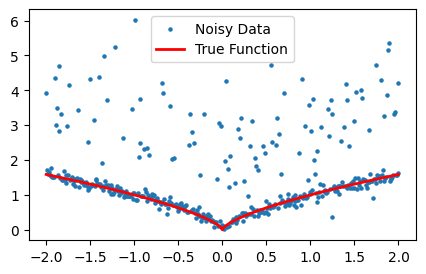

In [13]:
## Just to visualize the function
np.random.seed(1)
x = np.arange(-2, 2.01, 0.01)  # Equivalent to seq(-2,2,0.01)
gi = g(x)
n = len(x)
s_g = 0.1; s_h = 1
delta = 0.27
n1 = int(n * delta)

# Generate errors
e = np.concatenate([np.random.normal(0, s_g, n - n1), np.random.normal(2, s_h, n1)])
np.random.shuffle(e)  # To ensure random placement of values
y = gi + e
X = x.reshape(-1,1)
Y = y.reshape(-1,1)

plt.figure(figsize=(5,3))
plt.scatter(x, y, s=5, label="Noisy Data")  # pch = 20 equivalent
plt.plot(x, gi, 'r-', linewidth=2, label="True Function")  # lines(x, gi, lwd = 2)
plt.legend()
plt.show()

## MLE, Huber, LTA, LTS

In [6]:
## MLE and Huber
x = np.arange(-2, 2.01, 0.01)  
n = len(x)
gi = g(x)
s_g = 0.1; s_h = 1
delta = 0       # Contamination proportion
n1 = int(n * delta)

def TMSE_MLE_Huber(r):
    np.random.seed(r)
    e = np.concatenate([np.random.normal(0, s_g, n - n1), np.random.normal(2, s_h, n1)]); np.random.shuffle(e)
    y = gi + e
    X = x.reshape(-1,1)
    Y = y.reshape(-1,1)
    
    n_epochs = 1000
    #### MLE / Usual Backpropagation
    # Define model
    model = keras.Sequential([
        keras.layers.Dense(5, input_shape=(1,), activation='relu', kernel_initializer=GlorotUniform(seed=42)),
        keras.layers.Dense(1, kernel_initializer=GlorotUniform(seed=42))
        ])
    # Model fitting MLE
    model.compile(optimizer='adam', loss='mse')
    model.fit(X, Y, epochs=n_epochs, verbose = 0)
    # Train data APE MLE
    mle_pred = model.predict(X, verbose=0).flatten()
    tmse = trimmed_mean((y - mle_pred) ** 2, trim_fraction=delta)
    # Test data APE MLE
    x_test = np.random.uniform(-2, 2, n); e_test = np.random.normal(0, s_g, n)
    y_test = g(x_test) + e_test
    X_test = x_test.reshape(-1,1)
    mle_pred_test = model.predict(X_test, verbose=0).flatten()
    mse_test = np.mean((y_test - mle_pred_test) ** 2)
    
    ## scale related estimates used for other methods
    diff = y-mle_pred; sig0 = sig_hat_MAD(diff)
    abs_diff = np.abs(diff); h = sum(abs_diff < 3*sig_hat_MAD(abs_diff))
    
    #### Huber
    # Define model
    model = keras.Sequential([
        keras.layers.Dense(5, input_shape=(1,), activation='relu', kernel_initializer=GlorotUniform(seed=42)),
        keras.layers.Dense(1, kernel_initializer=GlorotUniform(seed=42))
        ])
    # Model fitting Huber
    model.compile(optimizer='adam', loss=HuberLoss(delta = 1.345, sig = sig0))
    model.fit(X, Y, epochs=n_epochs, verbose = 0)
    # Train data APE Huber
    huber_pred = model.predict(X, verbose=0).flatten()
    tmse_huber = trimmed_mean((y - huber_pred) ** 2, trim_fraction=delta)
    # Test data APE MLE
    huber_pred_test = model.predict(X_test, verbose=0).flatten()
    mse_test_huber = np.mean((y_test - huber_pred_test) ** 2)
    
    #### LTA
    # Define model
    model = keras.Sequential([
        keras.layers.Dense(5, input_shape=(1,), activation='relu', kernel_initializer=GlorotUniform(seed=42)),
        keras.layers.Dense(1, kernel_initializer=GlorotUniform(seed=42))
        ])
    # Model fitting
    model.compile(optimizer='adam', loss=LTALoss(h=h))
    model.fit(X, Y, epochs=n_epochs, verbose = 0)
    # Train data APE Huber
    lta_pred = model.predict(X, verbose=0).flatten()
    tmse_lta = trimmed_mean((y - lta_pred) ** 2, trim_fraction=delta)
    # Test data APE MLE
    lta_pred_test = model.predict(X_test, verbose=0).flatten()
    mse_test_lta = np.mean((y_test - lta_pred_test) ** 2)
    
    #### LTS
    # Define model
    model = keras.Sequential([
        keras.layers.Dense(5, input_shape=(1,), activation='relu', kernel_initializer=GlorotUniform(seed=42)),
        keras.layers.Dense(1, kernel_initializer=GlorotUniform(seed=42))
        ])
    # Model fitting
    model.compile(optimizer='adam', loss=LTSLoss(h=h))
    model.fit(X, Y, epochs=n_epochs, verbose = 0)
    # Train data APE Huber
    lts_pred = model.predict(X, verbose=0).flatten()
    tmse_lts = trimmed_mean((y - lts_pred) ** 2, trim_fraction=delta)
    # Test data APE MLE
    lts_pred_test = model.predict(X_test, verbose=0).flatten()
    mse_test_lts = np.mean((y_test - lts_pred_test) ** 2)

    return [tmse, mse_test, tmse_huber, mse_test_huber, tmse_lta, mse_test_lta, tmse_lts, mse_test_lts, sig0, h]

In [7]:
#TMSE_MLE_Huber(0)

In [ ]:
print('cont prop:', delta)

start = time.time()
result_list_mle = Parallel(n_jobs = -1)(delayed(TMSE_MLE_Huber)(r) for r in range(1000))
end = time.time()
TAPE_mle = np.array(result_list_mle)
print('Result shape:', TAPE_mle.shape)
print('time taken:', end-start)
# Answer reported in paper
pd.DataFrame(np.mean(TAPE_mle, axis = 0)[:8].reshape(-1,2),columns=['train','test'], index=['MLE','Huber','LTA','LTS'])

cont prop: 0


2025-02-17 13:45:32.450030: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-17 13:45:32.450030: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-17 13:45:32.453598: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-17 13:45:32.453598: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-17 13:45:32.453681: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-17 13:45:32.457225: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-17 13:45:32.464834: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cu

Result shape: (1000, 10)
time taken: 9296.804971694946


,train,test
MLE,0.011441,0.011762
Huber,0.011719,0.012037
LTA,0.012124,0.012387
LTS,0.011441,0.011763


In [9]:
df = pd.DataFrame(TAPE_mle)
df1 = pd.DataFrame(np.mean(TAPE_mle, axis = 0)[:8].reshape(-1,2),columns=['train','test'], index=['MLE','Huber','LTA','LTS'])
aa = ['tmse_mle', 'mse_mle_test', 'tmse_huber', 'mse_huber_test', 'tmse_lta', 'mse_lta', 'tmse_lts', 'mse_lts', 'sig0','h']
df.to_csv("TAPE_comp_0.csv", index=False, header=aa)
df1.to_csv("TAPE_comp_result_0.csv")

## Tukey, LMLS

In [14]:
T222 = pd.read_csv('TAPE_comp_0.csv')['sig0']

## Tukey, LMLS
x = np.arange(-2, 2.01, 0.01)  
n = len(x)
gi = g(x)
s_g = 0.1; s_h = 1
delta = 0       # Contamination proportion
n1 = int(n * delta)

def TMSE_Tukey_LMLS(r):
    np.random.seed(r)
    e = np.concatenate([np.random.normal(0, s_g, n - n1), np.random.normal(2, s_h, n1)]); np.random.shuffle(e)
    y = gi + e
    Y = y.reshape(-1,1)
    sig0 = T222[r]
    
    n_epochs = 1000
    #### Tukey
    # Define model
    model = keras.Sequential([
        keras.layers.Dense(7, activation='relu', kernel_initializer=GlorotUniform(seed=42)),
        keras.layers.Dense(1, kernel_initializer=GlorotUniform(seed=42))
        ])
    # Model fitting Tukey
    model.compile(optimizer='adam', loss=TukeyLoss(delta = 4.685, sig = sig0))
    model.fit(X, Y, epochs=n_epochs, verbose = 0)
    # Train data APE Tukey
    tukey_pred = model.predict(X, verbose=0).flatten()
    tmse_tukey = trimmed_mean((y - tukey_pred) ** 2, trim_fraction=delta)
    # Test data APE MLE
    x_test = np.random.uniform(-2, 2, n); e_test = np.random.normal(0, s_g, n)
    y_test = g(x_test) + e_test
    X_test = x_test.reshape(-1,1)
    tukey_pred_test = model.predict(X_test, verbose=0).flatten()
    mse_test_tukey = np.mean((y_test - tukey_pred_test) ** 2)
    
    #### LMLS
    # Define model
    model = keras.Sequential([
        keras.layers.Dense(5, activation='relu', kernel_initializer=GlorotUniform(seed=42)),
        keras.layers.Dense(1, kernel_initializer=GlorotUniform(seed=42))
        ])
    # Model fitting
    model.compile(optimizer='adam', loss=LMLSLoss())
    model.fit(X, Y, epochs=n_epochs, verbose = 0)
    # Train data APE Huber
    lmls_pred = model.predict(X, verbose=0).flatten()
    tmse_lmls = trimmed_mean((y - lmls_pred) ** 2, trim_fraction=delta)
    # Test data APE MLE
    lmls_pred_test = model.predict(X_test, verbose=0).flatten()
    mse_test_lmls = np.mean((y_test - lmls_pred_test) ** 2)
    
    return [tmse_tukey, mse_test_tukey, tmse_lmls, mse_test_lmls]

In [ ]:
print('cont prop:', delta)

start = time.time()
result_list_mle = Parallel(n_jobs = -1)(delayed(TMSE_Tukey_LMLS)(r) for r in range(1000))
end = time.time()
TAPE_mle = np.array(result_list_mle)
print('Result shape:', TAPE_mle.shape)
print('time taken:', end-start)
# Answer reported in paper
pd.DataFrame(np.mean(TAPE_mle, axis = 0).reshape(-1,2),columns=['train','test'], index=['Tukey','LMLS'])

cont prop: 0


2025-02-22 13:10:43.686338: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-22 13:10:43.686335: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-22 13:10:43.690056: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-22 13:10:43.690081: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-22 13:10:43.692189: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-22 13:10:43.695463: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-22 13:10:43.695642: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on 

Result shape: (1000, 4)
time taken: 4589.512470006943


,train,test
Tukey,0.012621,0.012775
LMLS,0.011511,0.011845


In [16]:
df = pd.DataFrame(TAPE_mle)
df1 = pd.DataFrame(np.mean(TAPE_mle, axis = 0).reshape(-1,2),columns=['train','test'], index=['Tukey','LMLS'])
aa = ['tmse_tukey', 'mse_test_tukey', 'tmse_lmls', 'mse_test_lmls']
df.to_csv("TAPE_TL_0.csv", index=False, header=aa)
df1.to_csv("TAPE_TL_result_0.csv")

# DPD

In [15]:
## DPD
x = np.arange(-2, 2.01, 0.01)  
n = len(x)
gi = g(x)
s_g = 0.1; s_h = 1
delta = 0       # Contamination proportion
n1 = int(n * delta)
al = np.array([0.1,0.3,0.5,0.7,1])

def TMSE(r, alpha):
    np.random.seed(r)
    e = np.concatenate([np.random.normal(0, s_g, n - n1), np.random.normal(2, s_h, n1)]); np.random.shuffle(e)
    y = gi + e
    X = x.reshape(-1,1)
    Y = y.reshape(-1,1)

    num_iterations = 10
    model = keras.Sequential([
        keras.layers.Dense(5, input_shape=(1,), activation='relu', kernel_initializer=GlorotUniform(seed=42)),
        keras.layers.Dense(1, kernel_initializer=GlorotUniform(seed=42))
        ])
    
    # Initial value of sigma
    sig0 = 1  # Set your initial sigma value
    for i in range(num_iterations):
        model.compile(optimizer=Adam(learning_rate=0.001), loss=CustomLoss(sigma = sig0, alpha=alpha))
        if(i>0):
            model.set_weights(weights)
        model.fit(X, Y, epochs = 100, verbose = 0)
        dpd_pred = model.predict(X, verbose=0)
        #print(dpd_pred.sum())
        weights = model.get_weights()
        #print(weights)
        diff = (Y - dpd_pred).flatten()
        sig0 = minimize(H, sig0, args = (alpha,diff), method='L-BFGS-B', bounds = [(0.001,10)]).x[0]
        #print(i, sig0)
    
    # Train data APE
    tmse = trimmed_mean((y - dpd_pred.flatten()) ** 2, trim_fraction=delta)
    
    # Test data APE
    x_test = np.random.uniform(-2, 2, n); e_test = np.random.normal(0, s_g, n)
    y_test = g(x_test) + e_test
    X_test = x_test.reshape(-1,1)
    dpd_pred_test = model.predict(X_test, verbose=0).flatten()
    mse_test = np.mean((y_test - dpd_pred_test) ** 2)
    
    return [tmse, mse_test]

def TMSE_arr(r):
    return np.array([TMSE(r, alpha) for alpha in al])

In [16]:
#TMSE_arr(0)

In [ ]:
print('cont prop:', delta)
start = time.time()
result_list = Parallel(n_jobs=-1)(delayed(TMSE_arr)(r) for r in range(1000))
end = time.time()
TAPE = np.array(result_list)
print(TAPE.shape)
print('time taken:', end-start)
TAPE

In [ ]:
print('cont prop:', delta)
start = time.time()
result_list = Parallel(n_jobs=100)(delayed(TMSE_arr)(r) for r in range(1000))
end = time.time()
TAPE = np.array(result_list)
# print(TAPE.shape)
# print('time taken:', end-start)
# TAPE

In [ ]:
# Answer reported in paper. 1st column is for Avg TMSE (on train data), 2nd Column is for Avg MSE (on test data)
APE = np.mean(TAPE, axis = 0)
APE

array([[0.01149488, 0.01183853],
       [0.01174344, 0.01205046],
       [0.01244603, 0.01266044],
       [0.0125367 , 0.01273427],
       [0.01293099, 0.01312978]])

In [ ]:
df = pd.DataFrame(APE, columns=['train', 'test'])
sqTAPE = TAPE**0.5
sqAPE = np.mean(sqTAPE, axis = 0)
df1 = pd.DataFrame(sqAPE, columns=['train', 'test'])
df.to_csv("APE_0.csv", index=False)
df1.to_csv("sqAPE_0.csv", index=False)

In [24]:
1+1

2